# 3. Posterior Analysis — Model 1 (Normal Likelihood, log-time)

## Model Specification

We model the **logarithm** of finish time, $y_i = \log(T_i)$, and back-transform predictions
with $T_i = \exp(y_i)$ so that all predicted finish times are strictly positive.

$$\log(T_i) \sim \text{Normal}(\mu_i, \sigma)$$
$$\mu_i = \alpha + \beta_{dist} \cdot \text{distance\_log\_std}_i + \beta_{elev} \cdot \text{elevation\_log\_std}_i$$

**Priors (log-time scale):**
- $\alpha \sim \text{Normal}(\log 10,\ 0.5)$ — typical race ~10 h
- $\beta_{dist} \sim \text{Normal}(0.6,\ 0.3)$ — $e^{0.6}\approx1.82\times$ per +1 SD log-distance
- $\beta_{elev} \sim \text{Normal}(0.2,\ 0.25)$ — $e^{0.2}\approx1.22\times$ per +1 SD log-elevation
- $\sigma \sim \text{Half-Normal}(0,\ 0.35)$ — residual SD on the log scale

The likelihood and the log-likelihood used for WAIC/LOO are both on `log_time`. Posterior
predictive replicates are drawn as `log_time_rep` and converted to hours via `time_rep = exp(log_time_rep)`.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az
from cmdstanpy import CmdStanModel
import warnings 
warnings.filterwarnings('ignore')

np.random.seed(42)
az.style.use('arviz-darkgrid')
plt.rcParams['figure.dpi'] = 110

# Load processed data
df_full = pd.read_csv('utmb_processed.csv')

# --- Log-time feature engineering (standardize on the full cleaned data, then subsample) ---
df_full = df_full[(df_full['Mean Finish Time'] > 0) &
                  (df_full['Distance'] > 0) &
                  (df_full['Elevation Gain'] >= 0)].copy()

df_full['log_time'] = np.log(df_full['Mean Finish Time'])
df_full['log_distance'] = np.log(df_full['Distance'])
df_full['log_elevation'] = np.log(df_full['Elevation Gain'] + 1)
df_full['steepness'] = df_full['Elevation Gain'] / df_full['Distance']

def standardise(s): return (s - s.mean()) / s.std()
df_full['distance_log_std']  = standardise(df_full['log_distance'])
df_full['elevation_log_std'] = standardise(df_full['log_elevation'])
df_full['log_steepness']     = np.log1p(df_full['steepness'])
df_full['steepness_std']     = standardise(df_full['log_steepness'])
if 'Elevation' in df_full.columns:
    df_full['altitude_std'] = standardise(df_full['Elevation'])
else:
    df_full['altitude_std'] = 0.0

# Subsample for computational feasibility
# (36K obs × 8000 posterior draws = ~2.3 GB per generated quantity array → kernel crash)
df = df_full.sample(n=5000, random_state=42).reset_index(drop=True)
print(f"Data: {df.shape[0]:,} observations (subsampled from {df_full.shape[0]:,})")
print(f"Categories: {df['Race Category'].value_counts().to_dict()}")
print(f"log_time range: [{df['log_time'].min():.3f}, {df['log_time'].max():.3f}]  "
      f"=> hours [{np.exp(df['log_time'].min()):.2f}, {np.exp(df['log_time'].max()):.2f}]")

Data: 5,000 observations (subsampled from 36,433)
Categories: {'50K': 2101, '20K': 1503, '100K': 1016, '100M': 380}
log_time range: [-0.136, 4.297]  => hours [0.87, 73.51]


In [2]:
# Prepare Stan data (response = log_time)
stan_data = {
    'N': len(df),
    'log_time':           df['log_time'].values.tolist(),
    'distance_log_std':   df['distance_log_std'].values.tolist(),
    'elevation_log_std':  df['elevation_log_std'].values.tolist(),
    'steepness_std':      df['steepness_std'].values.tolist(),
    'altitude_std':       df['altitude_std'].values.tolist(),
}

# Compile and fit Model 1
model1 = CmdStanModel(stan_file='model1_normal.stan')
print("Model 1 (Normal, log-time) compiled.")

19:59:49 - cmdstanpy - INFO - compiling stan file /workspace/utmb_race_finish_times_bayesian_analysis-unified_log_model/model1_normal.stan to exe file /workspace/utmb_race_finish_times_bayesian_analysis-unified_log_model/model1_normal


20:00:02 - cmdstanpy - INFO - compiled model executable: /workspace/utmb_race_finish_times_bayesian_analysis-unified_log_model/model1_normal


Model 1 (Normal, log-time) compiled.


In [3]:
# Fit Model 1
fit1 = model1.sample(
    data=stan_data,
    chains=4,
    iter_sampling=1000,
    iter_warmup=1000,
    seed=42,
    show_progress=True
)
print("Sampling complete.")

20:00:02 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

20:01:36 - cmdstanpy - INFO - CmdStan done processing.
20:01:36 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'model1_normal.stan', line 74, column 2 to column 31)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'model1_normal.stan', line 74, column 2 to column 31)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'model1_normal.stan', line 74, column 2 to column 31)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'model1_normal.stan', line 74, column 2 to column 31)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'model1_normal.stan', line 74, column 2 to column 31)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'model1_normal.stan', line 74, column 2 to column 31)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'model1_normal.stan', line 74, column 2 to colu


Sampling complete.


## 3.1 Sampling Diagnostics

We check:
- R-hat (should be < 1.01)
- ESS bulk and tail (should be > 400)
- Divergences (should be 0)
- Trace plots (chains should be well-mixed)

In [4]:
# Convert to ArviZ InferenceData (log-time scale)
idata1 = az.from_cmdstanpy(
    fit1,
    posterior_predictive='log_time_rep',
    log_likelihood='log_lik',
    observed_data={'log_time': df['log_time'].values}
)

# Print summary of key parameters
print("=" * 70)
print("MODEL 1 (Normal, log-time) — Posterior Summary")
print("=" * 70)
summary1 = az.summary(idata1, var_names=['alpha', 'beta_dist', 'beta_elev', 'beta_steep', 'beta_alt', 'sigma'])
print(summary1.to_string())

MODEL 1 (Normal, log-time) — Posterior Summary
             mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
alpha       2.100  0.003   2.095    2.105      0.000    0.000    3786.0    2535.0    1.0
beta_dist   1.817  0.083   1.662    1.966      0.003    0.002     878.0    1351.0    1.0
beta_elev  -1.299  0.097  -1.474   -1.116      0.003    0.002     878.0    1344.0    1.0
beta_steep  1.070  0.071   0.939    1.200      0.002    0.001     876.0    1348.0    1.0
beta_alt    0.028  0.003   0.023    0.032      0.000    0.000    3452.0    2216.0    1.0
sigma       0.182  0.002   0.179    0.186      0.000    0.000    1945.0    2000.0    1.0


In [5]:
# Check for sampling issues
print("\n=== MCMC Diagnostics ===")

# Divergences
divergences = fit1.diagnose()
print(f"\nDiagnostics output:")
print(divergences)


=== MCMC Diagnostics ===

Diagnostics output:
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [6]:
# R-hat and ESS check
rhat_vals = summary1['r_hat'].values
ess_bulk_vals = summary1['ess_bulk'].values
ess_tail_vals = summary1['ess_tail'].values

print("R-hat values:")
for param, rhat in zip(summary1.index, rhat_vals):
    status = '✓' if rhat < 1.01 else '✗ WARNING'
    print(f"  {param}: {rhat:.4f} {status}")

print(f"\nESS bulk (min): {ess_bulk_vals.min():.0f} {'✓' if ess_bulk_vals.min() > 400 else '✗ WARNING'}")
print(f"ESS tail (min): {ess_tail_vals.min():.0f} {'✓' if ess_tail_vals.min() > 400 else '✗ WARNING'}")

print(f"\nAll R-hat < 1.01: {all(rhat_vals < 1.01)}")
print(f"All ESS_bulk > 400: {all(ess_bulk_vals > 400)}")
print(f"All ESS_tail > 400: {all(ess_tail_vals > 400)}")

R-hat values:
  alpha: 1.0000 ✓
  beta_dist: 1.0000 ✓
  beta_elev: 1.0000 ✓
  beta_steep: 1.0000 ✓
  beta_alt: 1.0000 ✓
  sigma: 1.0000 ✓

ESS bulk (min): 876 ✓
ESS tail (min): 1344 ✓

All R-hat < 1.01: True
All ESS_bulk > 400: True
All ESS_tail > 400: True


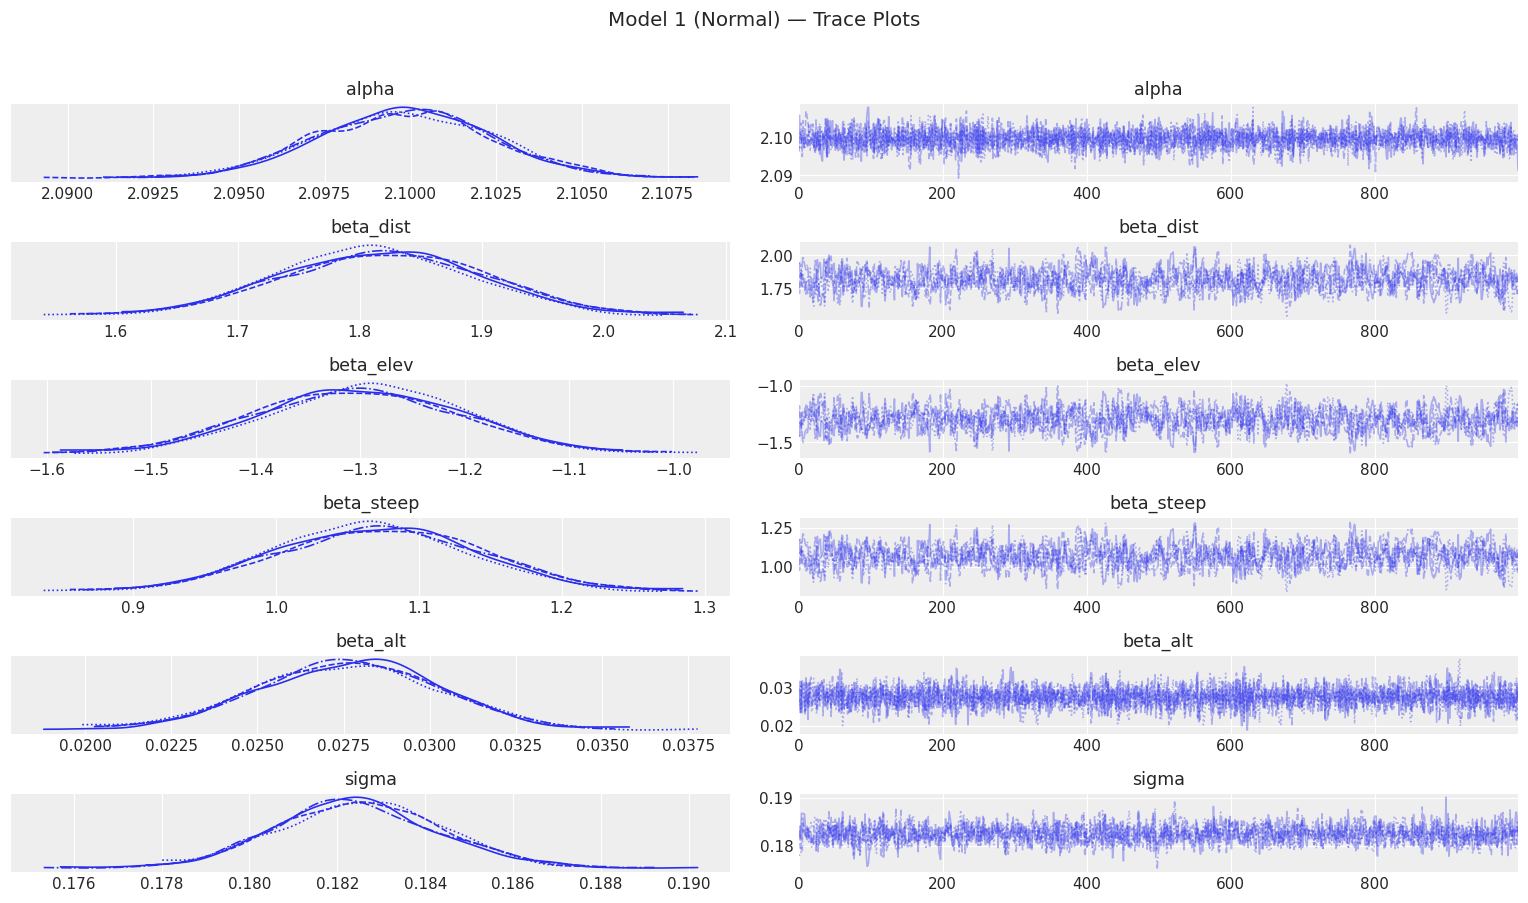


Trace plot assessment:
  → Chains should look like well-mixed 'fuzzy caterpillars'
  → No visible trends, stuck periods, or chain disagreements


In [7]:
# Trace plots
fig = az.plot_trace(idata1, var_names=['alpha', 'beta_dist', 'beta_elev', 'beta_steep', 'beta_alt', 'sigma'],
                    figsize=(14, 8), compact=True)
plt.suptitle('Model 1 (Normal) — Trace Plots', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig05_model1_trace.png', bbox_inches='tight')
plt.show()

print("\nTrace plot assessment:")
print("  → Chains should look like well-mixed 'fuzzy caterpillars'")
print("  → No visible trends, stuck periods, or chain disagreements")

### Sampling Assessment

Model 1 is a simple linear regression with conjugate-like structure. We expect:
- No divergences (simple geometry)
- Excellent mixing (R-hat ≈ 1.00, high ESS)
- Well-mixed trace plots

If any issues arise, potential mitigations:
- Increase `iter_sampling` (for low ESS)
- Increase `adapt_delta` (for divergences)
- Check for parameter correlations (pairs plot)

## 3.2 Posterior Predictive Distribution

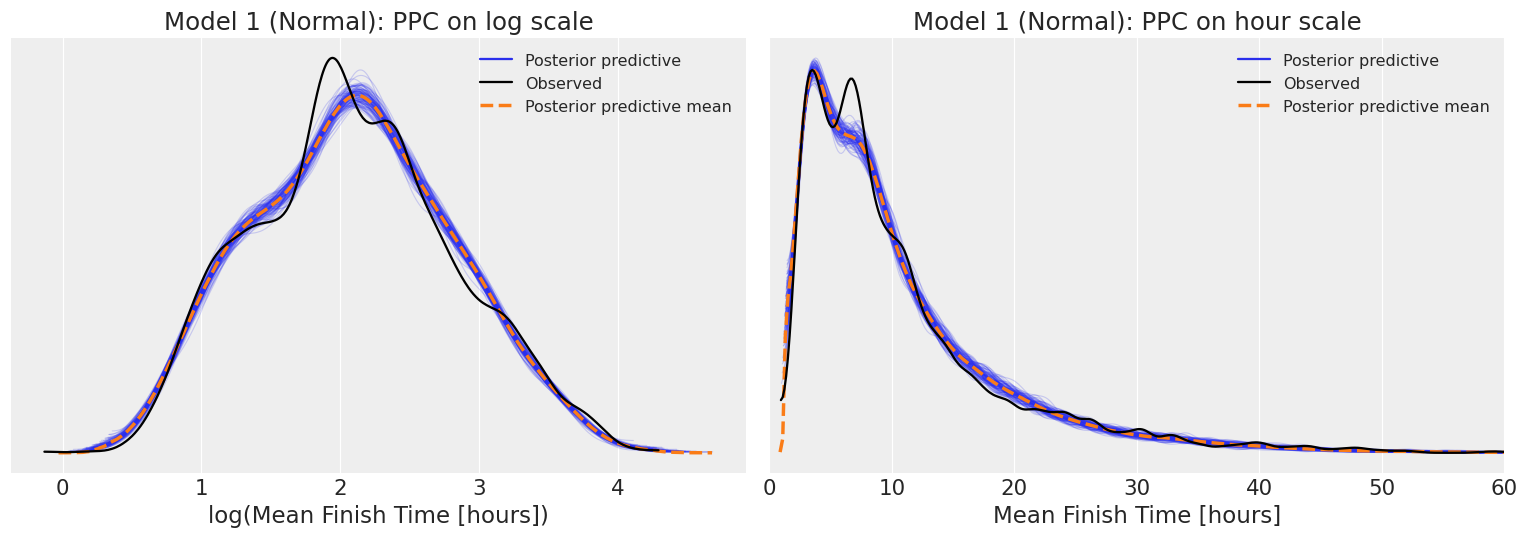

In [23]:
# Posterior predictive check — overall
# The model is fit on log_time; we inspect both the log scale and the hour scale.

y_obs = df['Mean Finish Time'].values      # observed finish time [hours]
log_obs = df['log_time'].values            # observed log-time

# Samples from Stan
log_time_rep_samples = fit1.stan_variable('log_time_rep')    # (draws, N), log-scale replicated data

# Back-transform posterior predictive samples to hours
time_rep_samples = np.exp(log_time_rep_samples)              # (draws, N)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------------------------------------------------
# Left: PPC on the LOG scale — this is the scale actually modeled
# -------------------------------------------------------------------
az.plot_ppc(
    idata1,
    data_pairs={'log_time': 'log_time_rep'},
    num_pp_samples=100,
    ax=axes[0]
)

axes[0].set_title('Model 1 (Normal): PPC on log scale')
axes[0].set_xlabel('log(Mean Finish Time [hours])')


# -------------------------------------------------------------------
# Right: PPC on the HOUR scale — back-transformed with exp()
# -------------------------------------------------------------------
idata_hours = az.from_dict(
    observed_data={
        "time": y_obs
    },
    posterior_predictive={
        "time_rep": time_rep_samples[None, :, :]
    }
)

az.plot_ppc(
    idata_hours,
    data_pairs={'time': 'time_rep'},
    num_pp_samples=100,
    ax=axes[1]
)

axes[1].set_title('Model 1 (Normal): PPC on hour scale')
axes[1].set_xlabel('Mean Finish Time [hours]')
axes[1].set_xlim(0, 60)  # Focus on the range of interest
plt.tight_layout()
plt.savefig('fig06_model1_ppc_overall.png', bbox_inches='tight', dpi=300)
plt.show()

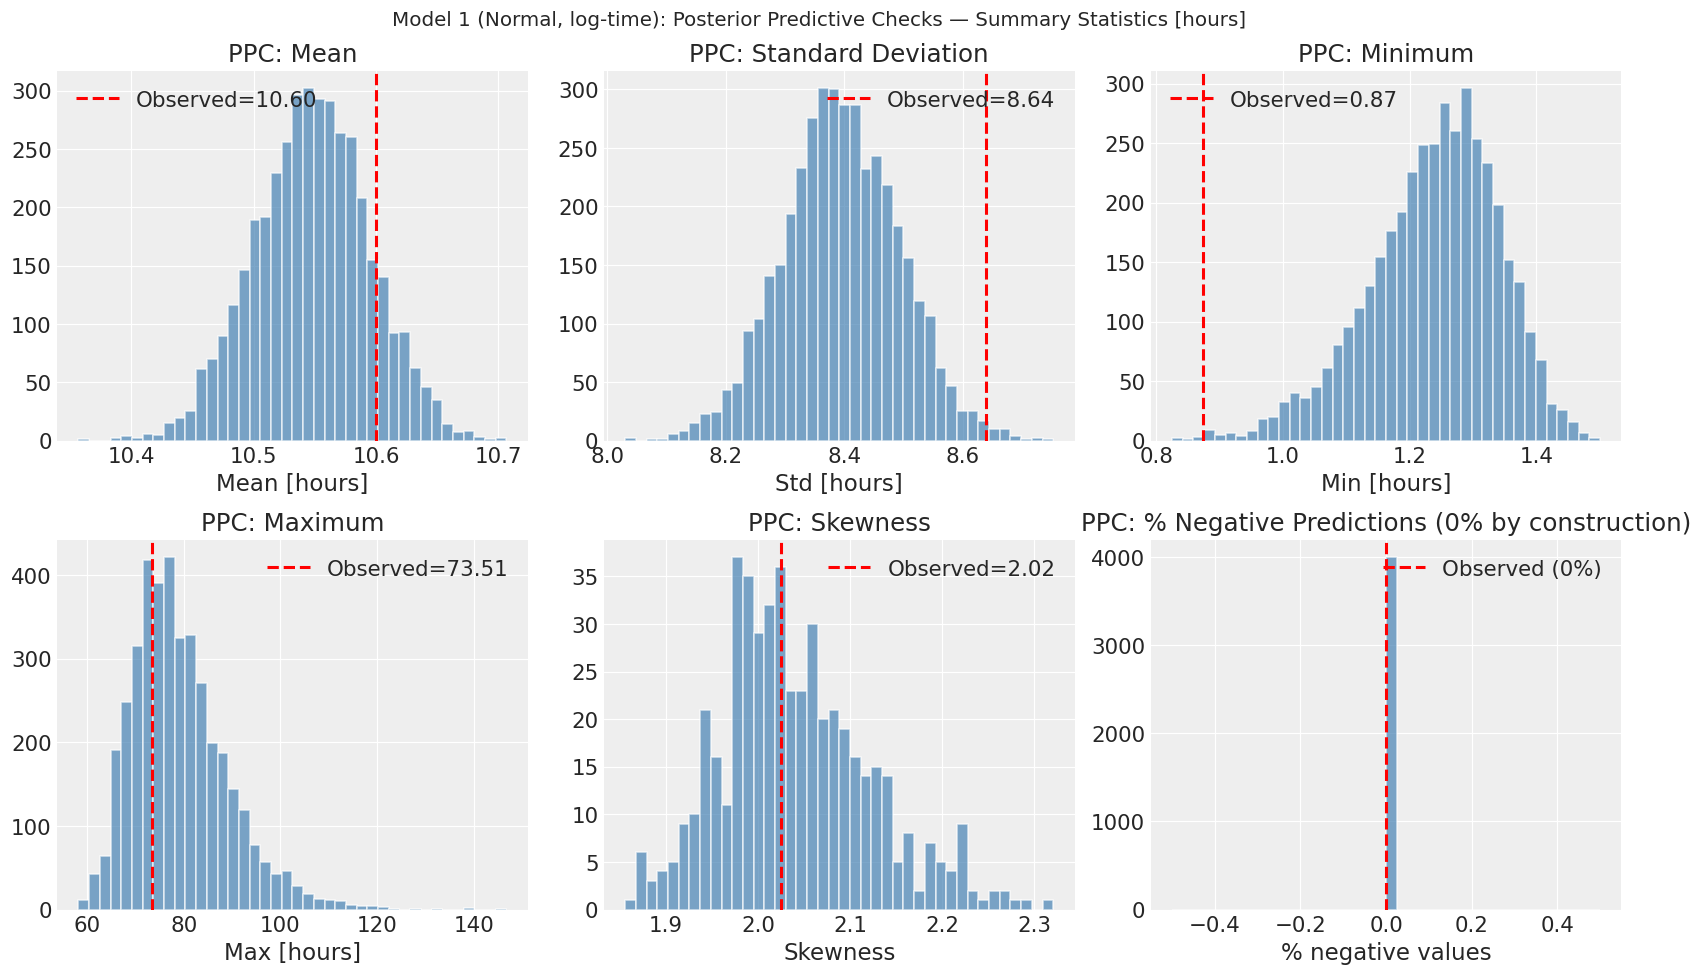

In [9]:
# Posterior predictive — summary statistics comparison (on the HOUR scale)
# Use back-transformed replicates time_rep = exp(log_time_rep).
y_rep_samples = time_rep_samples
n_samples = y_rep_samples.shape[0]

# Compute statistics for each posterior predictive sample
pp_means = y_rep_samples.mean(axis=1)
pp_stds = y_rep_samples.std(axis=1)
pp_mins = y_rep_samples.min(axis=1)
pp_maxs = y_rep_samples.max(axis=1)
pp_skew = np.array([stats.skew(y_rep_samples[s]) for s in range(min(500, n_samples))])

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Mean
axes[0,0].hist(pp_means, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[0,0].axvline(y_obs.mean(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.mean():.2f}')
axes[0,0].set_title('PPC: Mean')
axes[0,0].set_xlabel('Mean [hours]')
axes[0,0].legend()

# Std
axes[0,1].hist(pp_stds, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[0,1].axvline(y_obs.std(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.std():.2f}')
axes[0,1].set_title('PPC: Standard Deviation')
axes[0,1].set_xlabel('Std [hours]')
axes[0,1].legend()

# Min
axes[0,2].hist(pp_mins, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[0,2].axvline(y_obs.min(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.min():.2f}')
axes[0,2].set_title('PPC: Minimum')
axes[0,2].set_xlabel('Min [hours]')
axes[0,2].legend()

# Max
axes[1,0].hist(pp_maxs, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[1,0].axvline(y_obs.max(), color='red', linewidth=2, linestyle='--', label=f'Observed={y_obs.max():.2f}')
axes[1,0].set_title('PPC: Maximum')
axes[1,0].set_xlabel('Max [hours]')
axes[1,0].legend()

# Skewness
axes[1,1].hist(pp_skew, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[1,1].axvline(stats.skew(y_obs), color='red', linewidth=2, linestyle='--', label=f'Observed={stats.skew(y_obs):.2f}')
axes[1,1].set_title('PPC: Skewness')
axes[1,1].set_xlabel('Skewness')
axes[1,1].legend()

# Proportion of negative predictions — should be exactly 0% by construction (exp > 0)
pp_neg_pct = (y_rep_samples < 0).mean(axis=1) * 100
axes[1,2].hist(pp_neg_pct, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[1,2].axvline(0, color='red', linewidth=2, linestyle='--', label='Observed (0%)')
axes[1,2].set_title('PPC: % Negative Predictions (0% by construction)')
axes[1,2].set_xlabel('% negative values')
axes[1,2].legend()

plt.suptitle('Model 1 (Normal, log-time): Posterior Predictive Checks — Summary Statistics [hours]', fontsize=13)
plt.tight_layout()
plt.savefig('fig07_model1_ppc_stats.png', bbox_inches='tight')
plt.show()

## 3.3 Data Consistency Assessment

We check if the observed data statistics fall within the posterior predictive distribution.

In [10]:
# Quantitative assessment
print("Model 1 (Normal) — Posterior Predictive Consistency Check")
print("=" * 65)

def ppc_pvalue(observed_stat, simulated_stats):
    """Bayesian p-value: proportion of simulated stats >= observed."""
    return np.mean(simulated_stats >= observed_stat)

stats_check = [
    ('Mean', y_obs.mean(), pp_means),
    ('Std Dev', y_obs.std(), pp_stds),
    ('Minimum', y_obs.min(), pp_mins),
    ('Maximum', y_obs.max(), pp_maxs),
    ('Skewness', stats.skew(y_obs), pp_skew),
]

print(f"{'Statistic':<15} {'Observed':<12} {'PP Median':<12} {'PP 95% CI':<25} {'p-value':<10} {'Status'}")
print("-" * 85)
for name, obs_val, pp_vals in stats_check:
    pp_med = np.median(pp_vals)
    pp_lo = np.percentile(pp_vals, 2.5)
    pp_hi = np.percentile(pp_vals, 97.5)
    pval = ppc_pvalue(obs_val, pp_vals)
    in_ci = pp_lo <= obs_val <= pp_hi
    status = '✓ consistent' if in_ci else '✗ INCONSISTENT'
    print(f"{name:<15} {obs_val:<12.3f} {pp_med:<12.3f} [{pp_lo:.2f}, {pp_hi:.2f}]{'':>5} {pval:<10.3f} {status}")

print("\n" + "=" * 65)
print("Interpretation:")
print("  - Statistics are computed on the HOUR scale (time_rep = exp(log_time_rep)).")
print("  - p-values near 0 or 1 indicate the model fails to capture that statistic")
print("  - p-values near 0.5 indicate good calibration")
print("  - Because the model is Normal on the LOG scale, predicted hours follow a")
print("    log-normal shape: right-skewed and strictly positive, which matches finish")
print("    times far better than a Normal on raw hours (no negative predictions).")

Model 1 (Normal) — Posterior Predictive Consistency Check
Statistic       Observed     PP Median    PP 95% CI                 p-value    Status
-------------------------------------------------------------------------------------
Mean            10.600       10.549       [10.46, 10.64]      0.131      ✓ consistent
Std Dev         8.640        8.394        [8.20, 8.59]      0.008      ✗ INCONSISTENT
Minimum         0.873        1.250        [1.01, 1.41]      0.999      ✗ INCONSISTENT
Maximum         73.507       77.594       [64.34, 102.90]      0.686      ✓ consistent
Skewness        2.025        2.028        [1.90, 2.22]      0.520      ✓ consistent

Interpretation:
  - Statistics are computed on the HOUR scale (time_rep = exp(log_time_rep)).
  - p-values near 0 or 1 indicate the model fails to capture that statistic
  - p-values near 0.5 indicate good calibration
  - Because the model is Normal on the LOG scale, predicted hours follow a
    log-normal shape: right-skewed and strictly

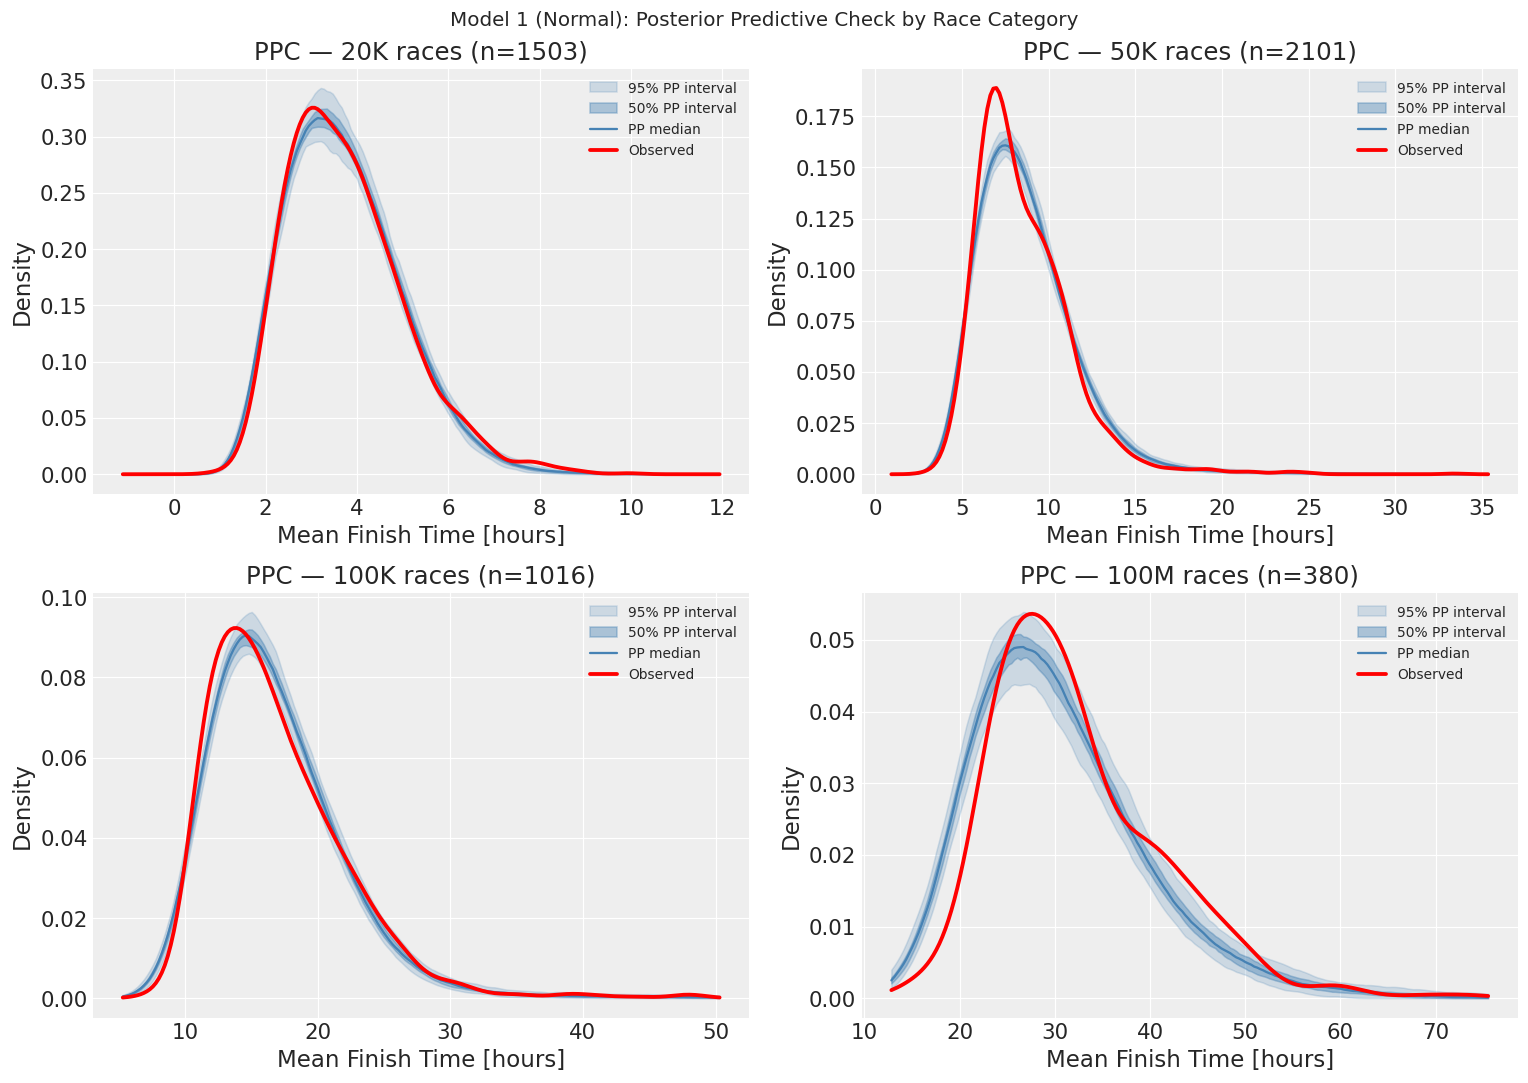

In [11]:
# PPC by race category — using KDE overlays for visibility
from scipy.stats import gaussian_kde

categories = ['20K', '50K', '100K', '100M']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, cat in enumerate(categories):
    ax = axes[idx // 2, idx % 2]
    mask = df['Race Category'].values == cat
    y_cat = y_obs[mask]
    y_rep_cat = y_rep_samples[:200, mask]  # use subset for speed
    
    # Plot posterior predictive as KDE envelope (more visible than alpha=0.02 histograms)
    x_grid = np.linspace(y_cat.min() - 2, y_cat.max() + 2, 200)
    kde_samples = np.zeros((min(100, y_rep_cat.shape[0]), len(x_grid)))
    for s in range(min(100, y_rep_cat.shape[0])):
        try:
            kde = gaussian_kde(y_rep_cat[s])
            kde_samples[s] = kde(x_grid)
        except:
            pass
    
    # Plot posterior predictive envelope (50% and 95% intervals)
    kde_lo = np.percentile(kde_samples, 2.5, axis=0)
    kde_hi = np.percentile(kde_samples, 97.5, axis=0)
    kde_med = np.median(kde_samples, axis=0)
    kde_q25 = np.percentile(kde_samples, 25, axis=0)
    kde_q75 = np.percentile(kde_samples, 75, axis=0)
    
    ax.fill_between(x_grid, kde_lo, kde_hi, alpha=0.2, color='steelblue', label='95% PP interval')
    ax.fill_between(x_grid, kde_q25, kde_q75, alpha=0.4, color='steelblue', label='50% PP interval')
    ax.plot(x_grid, kde_med, color='steelblue', linewidth=1.5, label='PP median')
    
    # Plot observed data KDE
    kde_obs = gaussian_kde(y_cat)
    ax.plot(x_grid, kde_obs(x_grid), color='red', linewidth=2.5, label='Observed')
    
    ax.set_title(f'PPC — {cat} races (n={mask.sum()})')
    ax.set_xlabel('Mean Finish Time [hours]')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9, framealpha=0.9)

plt.suptitle('Model 1 (Normal): Posterior Predictive Check by Race Category', fontsize=13)
plt.tight_layout()
plt.savefig('fig08_model1_ppc_categories.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.4 Marginal Posterior Distributions

We analyze the posterior marginal distributions of all parameters.

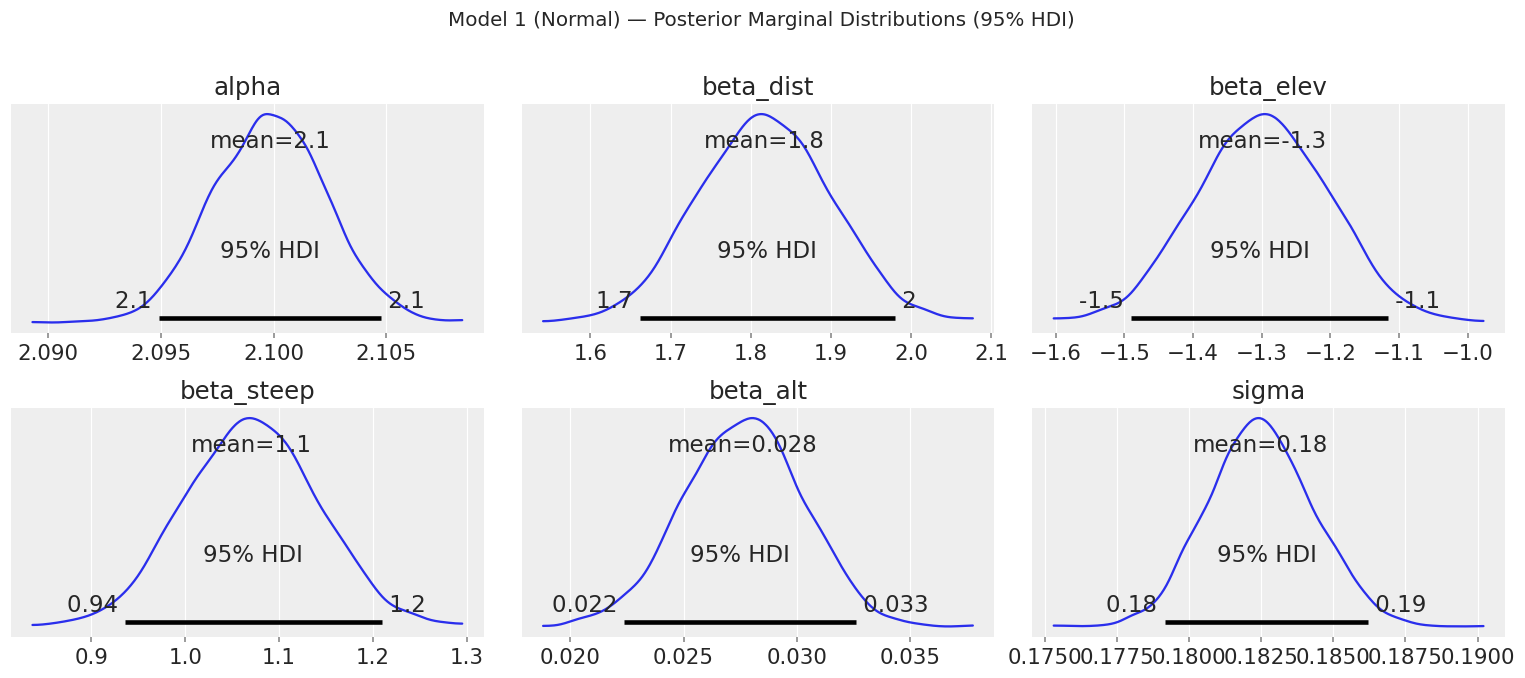

In [12]:
# Posterior marginal distributions
fig = az.plot_posterior(idata1, var_names=['alpha', 'beta_dist', 'beta_elev', 'beta_steep', 'beta_alt', 'sigma'],
                        figsize=(14, 6), hdi_prob=0.95)
plt.suptitle('Model 1 (Normal) — Posterior Marginal Distributions (95% HDI)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig09_model1_posteriors.png', bbox_inches='tight')
plt.show()

In [13]:
# Detailed parameter analysis (log-time scale; exp() gives multiplicative effects)
print("Model 1 (Normal, log-time) — Parameter Interpretation")
print("=" * 65)

# Extract posterior samples
alpha_post = idata1.posterior['alpha'].values.flatten()
beta_dist_post = idata1.posterior['beta_dist'].values.flatten()
beta_elev_post = idata1.posterior['beta_elev'].values.flatten()
sigma_post = idata1.posterior['sigma'].values.flatten()

print(f"\n--- alpha (intercept, log scale) ---")
print(f"  Posterior mean: {alpha_post.mean():.3f}  =>  exp(alpha) = {np.exp(alpha_post.mean()):.2f} h")
print(f"  95% HDI (hours): [{np.exp(np.percentile(alpha_post, 2.5)):.2f}, {np.exp(np.percentile(alpha_post, 97.5)):.2f}]")
print(f"  Interpretation: finish time for a race with average (log) distance & elevation.")

print(f"\n--- beta_dist (log-distance effect) ---")
print(f"  Posterior mean: {beta_dist_post.mean():.3f} (log scale)")
print(f"  95% HDI: [{np.percentile(beta_dist_post, 2.5):.3f}, {np.percentile(beta_dist_post, 97.5):.3f}]")
print(f"  Multiplicative: x{np.exp(beta_dist_post.mean()):.2f} per +1 SD of log-distance")
print(f"  P(beta_dist > 0): {(beta_dist_post > 0).mean():.4f}")

print(f"\n--- beta_elev (log-elevation effect) ---")
print(f"  Posterior mean: {beta_elev_post.mean():.3f} (log scale)")
print(f"  95% HDI: [{np.percentile(beta_elev_post, 2.5):.3f}, {np.percentile(beta_elev_post, 97.5):.3f}]")
print(f"  Multiplicative: x{np.exp(beta_elev_post.mean()):.2f} per +1 SD of log-elevation")
print(f"  P(beta_elev > 0): {(beta_elev_post > 0).mean():.4f}")

print(f"\n--- sigma (residual SD, log scale) ---")
print(f"  Posterior mean: {sigma_post.mean():.3f}")
print(f"  95% HDI: [{np.percentile(sigma_post, 2.5):.3f}, {np.percentile(sigma_post, 97.5):.3f}]")
print(f"  Interpretation: residual multiplicative spread of about "
      f"+{(np.exp(sigma_post.mean())-1)*100:.0f}% / -{(1-np.exp(-sigma_post.mean()))*100:.0f}% (~1 SD).")

print(f"\n--- Concentration/Diffusion ---")
print(f"  alpha CV:     {alpha_post.std()/abs(alpha_post.mean())*100:.1f}%")
print(f"  beta_dist CV: {beta_dist_post.std()/abs(beta_dist_post.mean())*100:.1f}%")
print(f"  beta_elev CV: {beta_elev_post.std()/abs(beta_elev_post.mean())*100:.1f}%")
print(f"  sigma CV:     {sigma_post.std()/abs(sigma_post.mean())*100:.1f}%")
print(f"  → Low CVs indicate well-identified (concentrated) posteriors.")

Model 1 (Normal, log-time) — Parameter Interpretation

--- alpha (intercept, log scale) ---
  Posterior mean: 2.100  =>  exp(alpha) = 8.16 h
  95% HDI (hours): [8.13, 8.21]
  Interpretation: finish time for a race with average (log) distance & elevation.

--- beta_dist (log-distance effect) ---
  Posterior mean: 1.817 (log scale)
  95% HDI: [1.656, 1.978]
  Multiplicative: x6.15 per +1 SD of log-distance
  P(beta_dist > 0): 1.0000

--- beta_elev (log-elevation effect) ---
  Posterior mean: -1.299 (log scale)
  95% HDI: [-1.487, -1.111]
  Multiplicative: x0.27 per +1 SD of log-elevation
  P(beta_elev > 0): 0.0000

--- sigma (residual SD, log scale) ---
  Posterior mean: 0.182
  95% HDI: [0.179, 0.186]
  Interpretation: residual multiplicative spread of about +20% / -17% (~1 SD).

--- Concentration/Diffusion ---
  alpha CV:     0.1%
  beta_dist CV: 4.6%
  beta_elev CV: 7.5%
  sigma CV:     1.0%
  → Low CVs indicate well-identified (concentrated) posteriors.


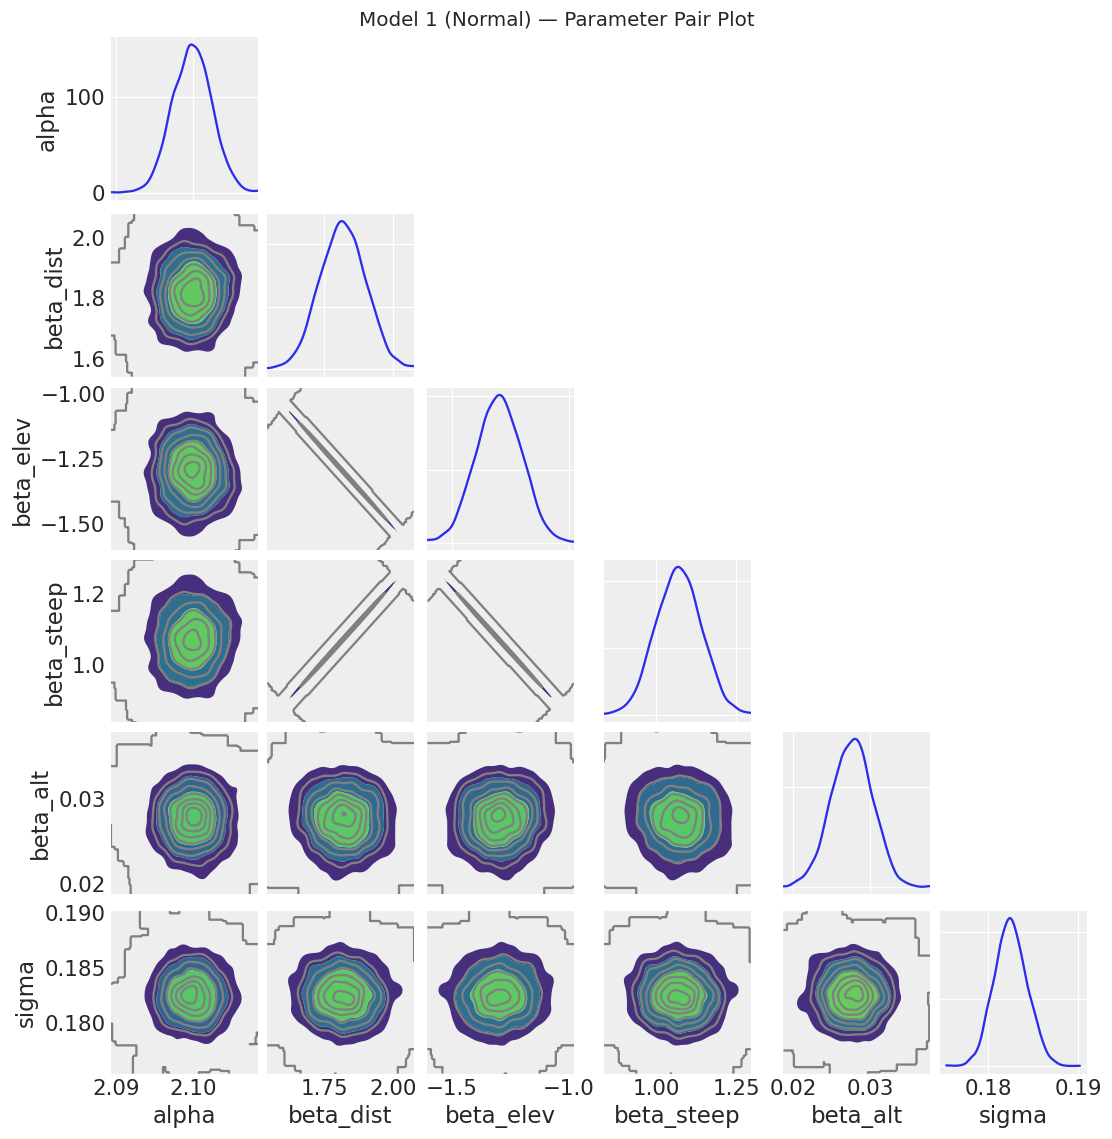


Pair plot assessment:
  → Check for strong correlations between parameters
  → Banana-shaped or multimodal posteriors indicate identification issues
  → Since predictors are standardized, alpha should be nearly independent of betas


In [14]:
# Pair plot — check for parameter correlations
fig = az.plot_pair(idata1, var_names=['alpha', 'beta_dist', 'beta_elev', 'beta_steep', 'beta_alt', 'sigma'],
                   kind='kde', figsize=(10, 10), marginals=True)
plt.suptitle('Model 1 (Normal) — Parameter Pair Plot', fontsize=13, y=1.02)
plt.savefig('fig10_model1_pairs.png', bbox_inches='tight')
plt.show()

print("\nPair plot assessment:")
print("  → Check for strong correlations between parameters")
print("  → Banana-shaped or multimodal posteriors indicate identification issues")
print("  → Since predictors are standardized, alpha should be nearly independent of betas")

## 3.5 Model 1 Summary and Limitations

### Strengths
- Simple, interpretable model; coefficients are multiplicative time factors ($e^\beta$).
- **Strictly positive predictions** — modelling `log_time` and back-transforming with `exp()` removes the negative-time problem of a Normal on raw hours.
- The log transform turns the multiplicative scaling of race time with distance/elevation into an approximately linear relationship and stabilizes variance (near-homoscedastic on the log scale).
- Fast sampling, no convergence issues expected.

### Potential Limitations
- Normal likelihood (on the log scale) assumes **symmetric, light-tailed** residuals in log-time.
- Outlier races (heavy log-tails) still inflate $\sigma$ for all predictions, since the Normal cannot down-weight them.
- No separate steepness term — terrain difficulty beyond distance/elevation is not modelled here.

These limitations motivate Model 2 (Student-t on log-time, with a steepness predictor), analyzed in the next notebook.